In [69]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from playwright.async_api import async_playwright
import time
import json
import asyncio
import requests
from bs4 import BeautifulSoup
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import statsmodels.api as sm
import warnings
from scipy import stats
from urllib.parse import urljoin, quote
import dash
from dash import dcc, html, Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px
import random
warnings.filterwarnings('ignore')

# Статический парсинг курсов со Степика

__Логика:__ для каждого навыка из определенных мною в первой части проекта я строю запросы к Степику и сохраняю ссылки на курсы, выдавшиеся по запросу на первых четырех страницах поиска, после чего захожу на каждый курс и достаю нужную информацию о нем. В Степике страница с отзывами является отдельной от основной страницы курса, поэтому для каждого курса я захожу на неё, чтобы получить инфу о количестве отзывов и средней оценке. При этом некоторые курсы могут появляться при запросах разных навыков. В таком случае курс не дублируется в датафрейме, а просто к нему в колонке Skills добавляются все подходящие навыки. 

In [2]:
# Такой же, как и в парсинге hh.ru, кроме удаленных категорий Soft skills и ИИ-инструменты - по ним особо нет курсов на Степике
skills_tree = {
    "Языки программирования": {
        "Python": ["Pandas", "NumPy"],
        "R": [],
        "Scala": [],
        "Java": [],
        "Bash": [],
    },
    "Базы и хранилища данных": {
        "DWH": [],
        "SQL": ["PostgreSQL", "MySQL", "SQLite", "Oracle"],
    },
    "Data Engineering": {
        "Spark": [],
        "Hadoop": [],
        "Kafka": [],
        "Airflow": [],
        "RabbitMQ": [],
    },
    "Машинное обучение": {
        "sklearn": [],
        "PyTorch": [],
    },
    "Интеграция данных": {
        "REST": [],
        "SOAP": [],
        "OpenAPI / Swagger": [],
    },
    "Статистика и математика": {
        "Теория вероятности": [],
        "Математическая статистика": [],
        "A/B тесты": [],
        "Регрессионный анализ": [],
        "Временные ряды": [],
    },
    "Визуализация и BI": {
        "Power BI": [],
        "Tableau": [],
    },
    "Таблицы": {
        "Excel": [],
        "Google Sheets": [],
        "Сводные таблицы": [],
        "Power Query": [],
    },
    "Продукт": {
        "Продуктовые метрики": [],
        "User stories": [],
        "Use cases": [],
    },
    "Моделирование бизнес-процессов": {
        "BPMN": [],
        "UML": [],
    },
    "Бизнес-системы": {
        "CRM": [],
        "1C": [],
    },
    "Управление проектами": {
        "Jira": [],
        "Miro": [],
        "Scrum": [],
        "Kanban": [],
    },
    "Документация и контроль версий": {
        "GitHub": [],
        "Confluence": [],
        "Notion": [],
    }
}

In [18]:
# Версия v1
class StepikScraper:
    api_url = "https://stepik.org/api/courses"
    review_url = "https://stepik.org/api/course-review-summaries/{}"
    course_url = "https://stepik.org/course/{}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    def __init__(self, skills_tree, pages_per_query, delay):
        self.skills_tree = skills_tree
        self.pages_per_query = pages_per_query
        self.delay = delay
        self.queries_ok = 0
        self.queries_failed = 0
        self.session = requests.Session()
        self.session.headers.update(self.headers)

    def build_query_to_skills(self):
        query_to_skills = {}
        for category, skills in self.skills_tree.items():
            for skill, subskills in skills.items():
                for term in [skill] + subskills:
                    if term not in query_to_skills:
                        query_to_skills[term] = set()
                    query_to_skills[term].add(term)
        return query_to_skills

    def get_page(self, query, page):
        params = {
            "search": query,
            "is_public": "true",
            "language": "ru",
            "page": page,
        }
        try:
            r = self.session.get(self.api_url, params=params, timeout=30)
            r.raise_for_status()
            self.queries_ok += 1
            return r.json()
        except Exception as e:
            self.queries_failed += 1
            print(f"Ошибка: запрос - {query!r}, страница - {page}, тип ошибки - {e}")
            return None

    def parse_course(self, raw, rating=None, reviews_count=None):
        return {
            "id": raw.get("id"),
            "title": raw.get("title"),
            "summary": raw.get("summary"),
            "language": raw.get("language"),
            "is_paid": raw.get("is_paid"),
            "price": raw.get("price"),
            "learners_count": raw.get("learners_count"),
            "rating": rating,
            "reviews_count": reviews_count,
            "url": self.course_url.format(raw.get("id")),
        }

    def get_query(self, query):
        raw_courses = {}
        for page in range(1, self.pages_per_query + 1):
            data = self.get_page(query, page)
            if data is None:
                break
            for raw in data.get("courses", []):
                cid = raw["id"]
                if cid not in raw_courses:
                    raw_courses[cid] = raw
            if not data.get("meta", {}).get("has_next", False):
                break
            time.sleep(random.uniform(*self.delay))
        return raw_courses

    def get_review_summary(self, review_id):
        try:
            r = self.session.get(self.review_url.format(review_id), timeout=30)
            r.raise_for_status()
            data = r.json()
            summary = data.get("course-review-summaries", [{}])[0]
            return summary.get("average"), summary.get("count")
        except Exception as e:
            print(f"Ошибка review summary: id - {review_id}, тип ошибки - {e}")
            return None, None

    def run(self):
        query_to_skills = self.build_query_to_skills()
        all_raw = {}
        course_skills = {}
        for query, skills in query_to_skills.items():
            fetched = self.get_query(query)
            for cid, raw in fetched.items():
                if cid not in all_raw:
                    all_raw[cid] = raw
                    course_skills[cid] = set()
                course_skills[cid].update(skills)
            time.sleep(random.uniform(*self.delay))

        print(f"Успешных запросов: {self.queries_ok}")
        print(f"Запросов с ошибкой: {self.queries_failed}")
        print(f"Уникальных курсов загружено: {len(all_raw)}")

        rows = []
        for cid, raw in all_raw.items():
            review_id = raw.get("review_summary")
            rating, reviews_count = self.get_review_summary(review_id) if review_id else (None, None)
            row = self.parse_course(raw, rating=rating, reviews_count=reviews_count)
            row["skills"] = course_skills[cid]
            rows.append(row)
            time.sleep(random.uniform(*self.delay))
        return pd.DataFrame(rows)

scraper = StepikScraper(skills_tree=skills_tree, pages_per_query=4, delay=(1, 4))
df = scraper.run()

Успешных запросов: 71
Запросов с ошибкой: 0
Уникальных курсов загружено: 797


In [21]:
df.head(5)

,id,title,summary,language,is_paid,price,learners_count,rating,reviews_count,url,skills
0,288622,Изучение Python с нуля,Базовый курс по языку программирования Python ...,ru,False,None,1,0.0,0,https://stepik.org/course/288622,{Python}
1,288416,"Python deque: очереди, стеки и буферы",Курс про collections.deque в Python: двусторон...,ru,True,599.00,2,0.0,0,https://stepik.org/course/288416,{Python}
2,288336,Python для начинающих.,Практический курс Python для начинающих: 10 мо...,ru,False,None,1,0.0,0,https://stepik.org/course/288336,{Python}
3,288278,Java для Python-разработчика,Курс знакомит опытных Python-разработчиков с я...,ru,False,None,6,0.0,0,https://stepik.org/course/288278,"{Python, Java}"
4,287941,Практикум по Python: от простых задач к алгори...,О курсе\n\nКурс предназначен для школьников и ...,ru,False,None,2,0.0,0,https://stepik.org/course/287941,{Python}


# Предобработка данных

Тут для каждого курса мы проходимся по описанию с помощью регулярных выражений (тех же, что и были при парсинге вакансий с hh.ru) и добавляем те навыки, которые еще не добавлены.

Отметим, что этот поиск не является идеальным. Например, если посмотреть на датафрейм выше, то в 3 строке можно увидеть "Java для Python-разработчика", который будет включать в себя как навыки Java, так и Python, в то время как должен включать только Java. Это неизбежная проблема при использовании регулярных выражений.

In [22]:
# Такие же, как и при парсинге hh.ru
reg_expressions = {
    "R": r"\bR\b",
    "SQL": r"\bSQL\b",
    "REST": r"\bREST(?:ful)?\b",
    "SOAP": r"\bSOAP\b",
    "OpenAPI / Swagger": r"\b(?:OpenAPI|Swagger)\b",
    "sklearn": r"\b(?:sklearn|scikit[-\s]learn)\b",
    "1C": r"(?<!\w)1[СCс](?!\w)",
    "A/B тесты": r"A/B[\s\-]?тест\w*",
    "Power BI": r"\bPower\s+BI\b",
    "Power Query": r"\bPower\s+Query\b",
    "Google Sheets": r"\bGoogle\s+Sheets\b",
    "RabbitMQ": r"\bRabbit\s*MQ\b",
    "ChatGPT": r"\bChat\s*GPT\b",
    "Сводные таблицы": r"сводн\w+\s+таблиц\w*",
    "Теория вероятности": r"теори\w+\s+вероятност\w*",
    "Математическая статистика": r"математическ\w+\s+статистик\w*",
    "Регрессионный анализ": r"регрессионн\w+\s+анализ\w*",
    "Временные ряды": r"временн\w+\s+ряд\w*",
    "Продуктовые метрики": r"продуктов\w+\s+метрик\w*",
    "Аналитическое мышление": r"аналитическ\w+\s+мышлени\w*",
    "Системное мышление": r"системн\w+\s+мышлени\w*",
    "Внимательность к деталям": r"внимательност\w+\s+к\s+деталям",
    "Грамотная речь": r"грамотн\w+\s+реч\w*",
    "User stories": r"\buser\s+stor(?:y|ies)\b",
    "Use cases": r"\buse\s+cases?\b",
}

In [23]:
all_skills = set()
for category, skills in skills_tree.items():
    for skill, subskills in skills.items():
        all_skills.add(skill)
        for subskill in subskills:
            all_skills.add(subskill)

def extract_skills_from_text(text):
    if not text:
        return set()
    result = set()
    for skill in all_skills:
        if skill in reg_expressions:
            pattern = reg_expressions[skill]
            if re.search(pattern, text, re.IGNORECASE):
                result.add(skill)
        else:
            if re.search(rf"\b{re.escape(skill)}\b", text, re.IGNORECASE):
                result.add(skill)
    return result

df['skills'] = df.apply(lambda row: row['skills'] | extract_skills_from_text(row['summary']), axis=1)

In [37]:
df['is_paid'] = df['is_paid'].replace({True: 1, False: 0})
df.loc[df['reviews_count'] == 0, 'rating'] = None # Если нет отзывов, то рейтинг заменяем на None
df['price'] = df['price'].fillna(0).astype('float')
df['course_revenue'] = df['learners_count']*df['price'].astype('float')

# Анализ данных

### 1. До агрегации по скиллам

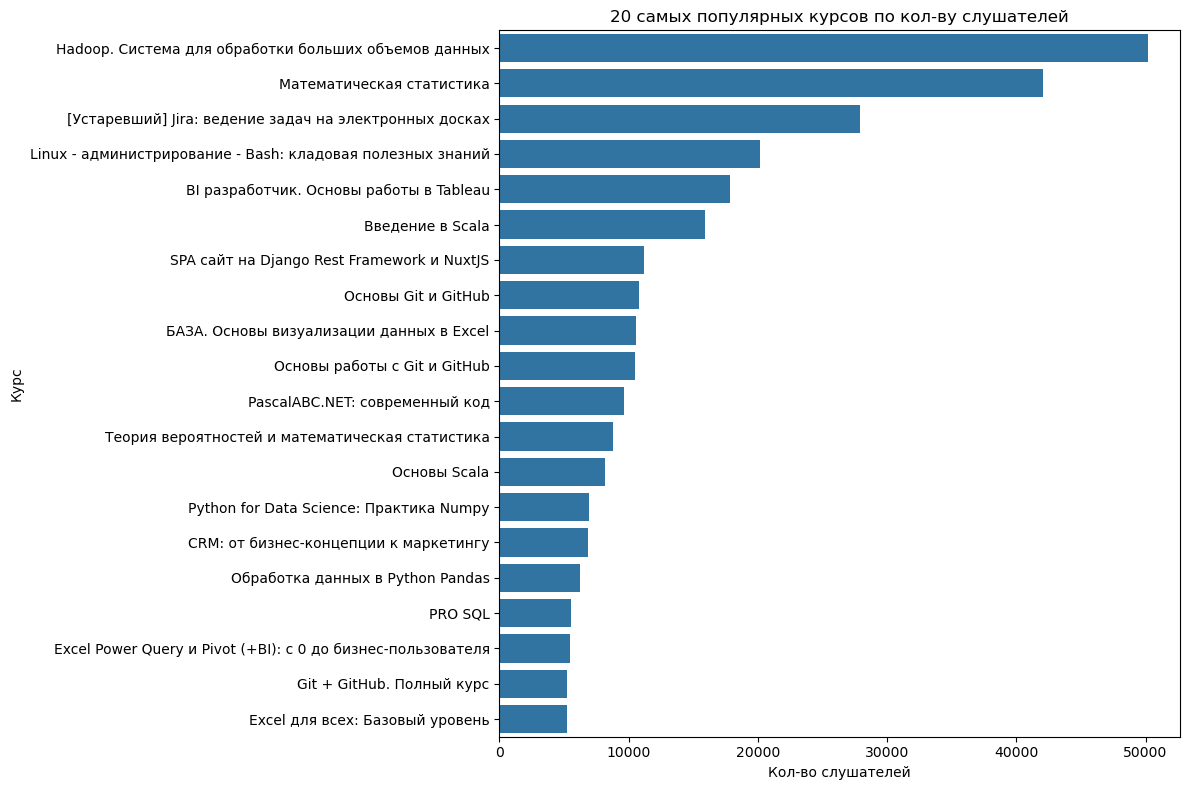

In [72]:
# Топ-20 самых популярных курсов по кол-ву слушателей
top_20 = df.nlargest(20, 'learners_count')
plt.figure(figsize=(12, 8))
sns.barplot(data=top_20, x='learners_count', y='title')
plt.title('20 самых популярных курсов по кол-ву слушателей')
plt.xlabel('Кол-во слушателей')
plt.ylabel('Курс')
plt.tight_layout()
plt.savefig('20_popular_courses.png')
plt.show()

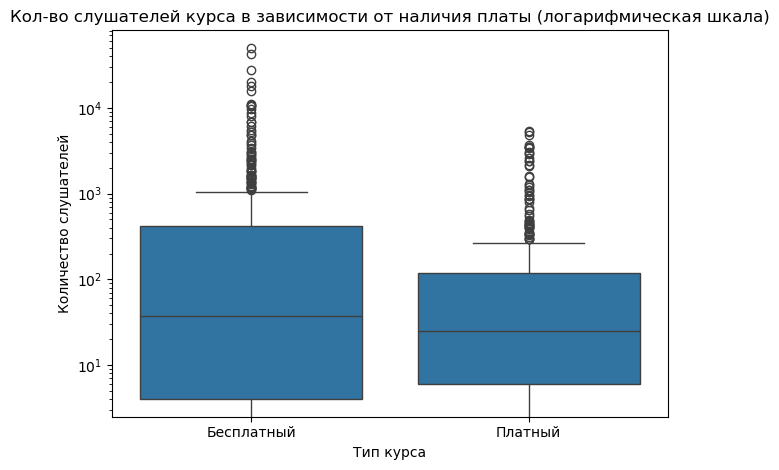

In [81]:
# Кол-во слушателей курса в зависимости от того, бесплатный он или платный - ЛОГАРИФМИЧЕСКАЯ ШКАЛА
ax = sns.boxplot(df, x = 'is_paid', y = 'learners_count')
ax.set_yscale('log')
ax.set_xlabel('Тип курса')
ax.set_xticklabels(['Бесплатный', 'Платный'])
ax.set_ylabel('Количество слушателей')
ax.set_title('Кол-во слушателей курса в зависимости от наличия платы (логарифмическая шкала)')
plt.tight_layout()
plt.savefig('free_and_paid_comparison.png', bbox_inches='tight')
plt.show()

In [29]:
# Т-тест для сравнения курсов по кол-ву слушателей
free = df[df['is_paid'] == 0]['learners_count']
paid = df[df['is_paid'] == 1]['learners_count']
stats.ttest_ind(free, paid)

TtestResult(statistic=np.float64(4.44572687855808), pvalue=np.float64(1.0004544274236221e-05), df=np.float64(795.0))

p-value < 0.05, поэтому принимаем альтернативную гипотезу: бесплатные курсы статистически значимо имеют больше слушателей, чем платные, что очень логично.

### 2. После агрегации по скиллам

In [62]:
df['rating_sum'] = (df['rating'] * df['reviews_count']).fillna(0)
exp_df = df.explode('skills')
skills_df = exp_df.groupby('skills').agg({
    'title': 'count', 'is_paid': 'sum', 'price': 'mean', 'course_revenue': 'sum', 'learners_count': 'sum', 'rating_sum': 'sum', 'reviews_count': 'sum'
}).reset_index()
skills_df['avg_rating'] = skills_df['rating_sum']/skills_df['reviews_count']
skills_df = skills_df.rename(columns={'title': 'total_courses'})

In [63]:
skills_df.head(5)

,skills,total_courses,is_paid,price,course_revenue,learners_count,rating_sum,reviews_count,avg_rating
0,1C,10,4,1277.900000,480602.0,2147,14.0,3,4.666667
1,A/B тесты,3,1,830.000000,276390.0,1342,155.0,32,4.843750
2,Airflow,7,7,17494.285714,12133000.0,2843,470.0,97,4.845361
3,BPMN,16,12,827.437500,2585486.0,6085,1938.0,398,4.869347
4,Bash,13,11,2762.230769,1150220.0,20724,793.0,164,4.835366


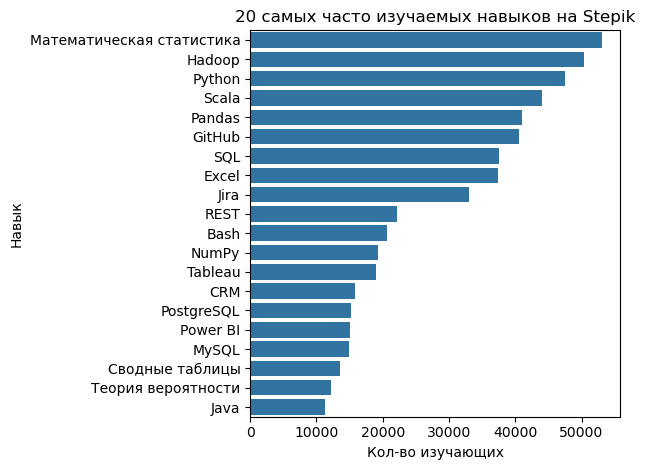

In [75]:
# Кол-во изучающих навыки (среди топ-20 самых часто изучаемых)
top_20 = skills_df.nlargest(20, 'learners_count')
sns.barplot(data=top_20, x='learners_count', y='skills')
plt.title('20 самых часто изучаемых навыков на Stepik')
plt.xlabel('Кол-во изучающих')
plt.ylabel('Навык')
plt.tight_layout()
plt.savefig('20_popular_skills.png')
plt.show()

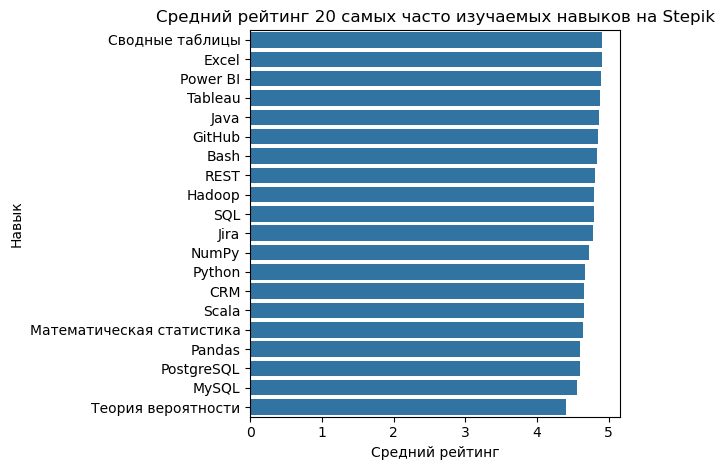

In [77]:
# Средние отзывы на курсы по навыкам
top_20 = skills_df.nlargest(20, 'learners_count')
top_20 = top_20.sort_values(by='avg_rating', ascending=False)
sns.barplot(data=top_20, x='avg_rating', y='skills')
plt.title('Средний рейтинг 20 самых часто изучаемых навыков на Stepik')
plt.xlabel('Средний рейтинг')
plt.ylabel('Навык')
plt.tight_layout()
plt.savefig('ratings_of_20_skills.png')
plt.show()

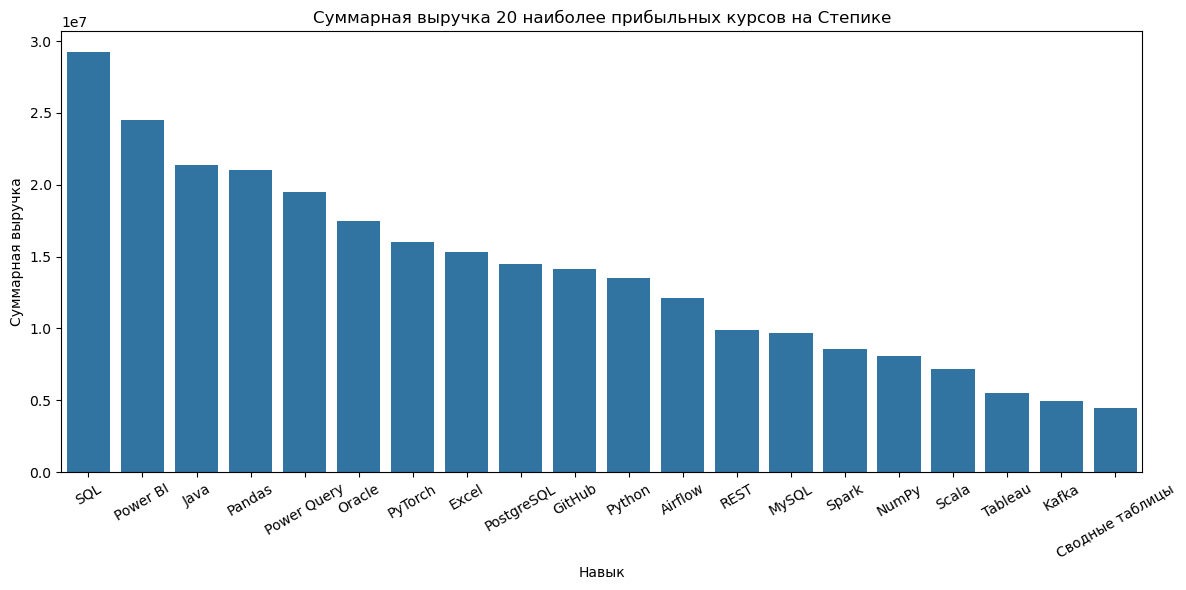

In [78]:
# Суммарная выручка курсов по каждому из навыков - для разнообразия сделаем вертикальный barplot
top_20 = skills_df.nlargest(20, 'course_revenue')
top_20 = top_20.sort_values(by='course_revenue', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_20, x='skills', y='course_revenue')
plt.title('Суммарная выручка 20 наиболее прибыльных курсов на Степике')
plt.xlabel('Навык')
plt.ylabel('Суммарная выручка')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('skills_revenue.png')
plt.show()

# Дэшборд с помощью dash

Дэшборд с бар-чартом, на котором можно выбирать метрику, по которой сортировать курсы и топ курсов, которые показывать.

In [71]:
metric_labels = {
    'learners_count': 'Слушатели (сумма)',
    'course_revenue': 'Выручка, ₽ (сумма)',
    'avg_rating': 'Рейтинг (взвешенное среднее)',
    'reviews_count': 'Отзывы (сумма)',
    'total_courses': 'Количество курсов',
}
 
def build_bar(metric, topn):
    top = skills_df.nlargest(topn, metric).sort_values(metric)
    fig = px.bar(top, x=metric, y='skills', orientation='h',
        color=metric,
        color_continuous_scale='Blues',
        labels={'skills': '', metric: metric_labels[metric]},
        title=f'Топ {topn} навыков — {metric_labels[metric]}',
        text=metric)
    fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
    fig.update_layout(coloraxis_showscale=False,
        height=max(350, topn * 28),
        margin=dict(l=10, r=70, t=50, b=40))
    return fig
 
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])
app.layout = dbc.Container([
    html.H1('Анализ курсов Степика по навыкам',
            className='text-center text-primary mb-4 mt-3'),
    dbc.Row([
        dbc.Col([
            dbc.Card([
                dbc.CardHeader('Фильтры'),
                dbc.CardBody([
                    html.Label('Метрика для бар-чарта', className='fw-bold'),
                    dcc.Dropdown(
                        id='metric-dd',
                        options=[{'label': v, 'value': k} for k, v in metric_labels.items()],
                        value='learners_count',
                        clearable=False,
                        className='mb-3',
                    ),
                    html.Label('Топ N навыков', className='fw-bold'),
                    dcc.Slider(id='topn-slider',
                        min=5, max=min(30, len(skills_df)), step=5, value=15,
                        marks={i: str(i) for i in range(5, min(35, len(skills_df) + 1), 5)},
                        tooltip={'placement': 'bottom'}),
                ]),
            ])
        ], md=4),
    ], className='mb-4'),
    dbc.Row([
        dbc.Col([
            dbc.Card([dbc.CardHeader('Топ навыков'),
                dbc.CardBody(dcc.Graph(id='bar-chart'))])
        ], md=12),
    ], className='mb-4'),
 
], fluid=True)
 
@app.callback(Output('bar-chart', 'figure'), [Input('metric-dd', 'value'), Input('topn-slider', 'value')])
def update_dashboard(metric, topn):
    return build_bar(metric, topn)
 
app.run(jupyter_mode='inline', port=8051)